# Actividad 1 - Regresión Lineal
# Predicción del precio de viviendas utilizando Machine Learning

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv('Housing.csv')

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


**Exploración Inicial**

In [3]:
print("Dimensiones:")
print(df.shape)

print("\nInformación:")
print(df.info())

print("\nValores nulos:")
print(df.isnull().sum())

Dimensiones:
(545, 13)

Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

Valores nulos:
price               0
area                0
bedrooms            0
bathrooms           0
stories 

In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


**Distribución del precio**

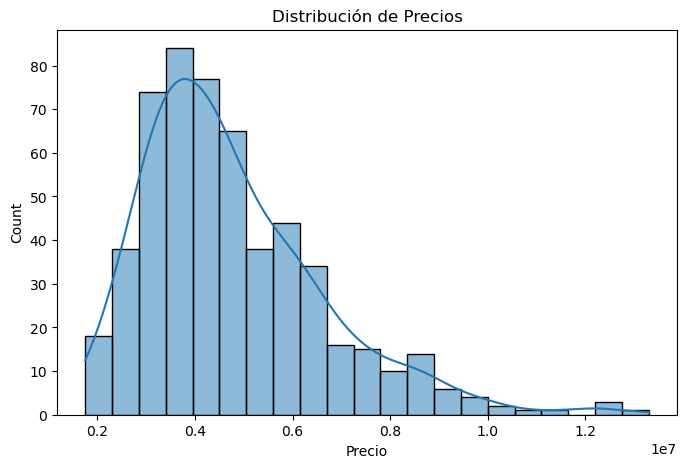

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], kde=True)

plt.title('Distribución de Precios')
plt.xlabel('Precio')

plt.show()

A partir del histograma se observa que la mayoría de las viviendas se concentran en rangos de precios medios. También se identifican algunas propiedades con precios considerablemente superiores al promedio, lo que genera una distribución asimétrica hacia la derecha.

**Correlación entre variables**

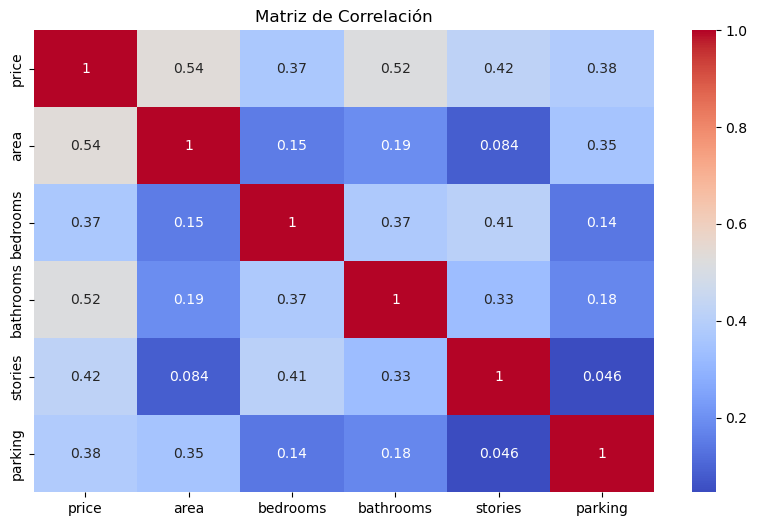

In [6]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Matriz de Correlación')

plt.show()

La matriz de correlación permitió identificar que las variables con mayor relación con el precio son el área de la vivienda (0.54) y la cantidad de baños (0.52). Esto sugiere que las propiedades más grandes y con más baños tienden a presentar valores de mercado más elevados.

**Variables categoricas**

In [8]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


**Variables predictoras y objetivo**

In [10]:
X = df.drop('price', axis=1)

y = df['price']

**División de los datos**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Entrenamiento**

In [12]:
modelo = LinearRegression()

modelo.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Predicciones**

In [13]:
y_pred = modelo.predict(X_test)

y_pred[:10]

array([5164653.90033967, 7224722.29802166, 3109863.24240338,
       4612075.32722559, 3294646.25725955, 3532275.09556559,
       5611774.56836476, 6368145.98732718, 2722856.95689985,
       2629405.61585782])

**Evaluación**

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 970043.4039201641
MSE: 1754318687330.6646
RMSE: 1324506.9600914388
R2: 0.6529242642153182


**Comparacion de los valores reales vs los predichos**

In [15]:
comparacion = pd.DataFrame({
    'Real': y_test,
    'Predicho': y_pred
})

comparacion.head(10)

,Real,Predicho
316,4060000,5.164654e+06
77,6650000,7.224722e+06
360,3710000,3.109863e+06
90,6440000,4.612075e+06
493,2800000,3.294646e+06
209,4900000,3.532275e+06
176,5250000,5.611775e+06
249,4543000,6.368146e+06
516,2450000,2.722857e+06
426,3353000,2.629406e+06


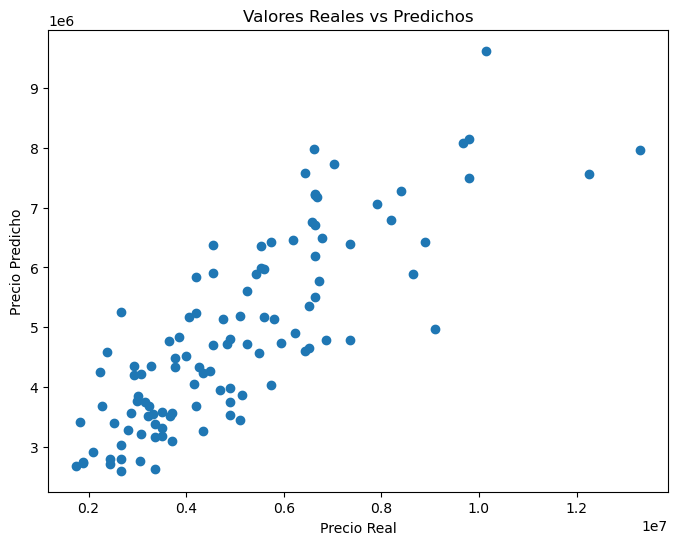

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")

plt.title("Valores Reales vs Predichos")

plt.show()

El gráfico de dispersión muestra una relación positiva entre los valores reales y los valores predichos. Aunque existe cierta dispersión entre los puntos, el modelo logra capturar la tendencia general de los datos, generando estimaciones razonables del precio de las viviendas.

# Conclusión

En esta actividad se aplicó un modelo de regresión lineal para predecir el precio de viviendas a partir de distintas características como el área, la cantidad de habitaciones, baños, pisos y espacios de estacionamiento.

Durante la etapa de exploración se analizaron las características generales del conjunto de datos, se verificó la ausencia de valores nulos y se estudió la relación entre las variables mediante una matriz de correlación. Los resultados mostraron que variables como el área y la cantidad de baños presentan una mayor relación con el precio de las viviendas.

Luego de preparar los datos y transformar las variables categóricas, se entrenó un modelo de regresión lineal utilizando un conjunto de entrenamiento y posteriormente se evaluó con datos de prueba.

El modelo obtuvo un coeficiente de determinación R² de 0,653, lo que indica que logra explicar aproximadamente el 65,3% de la variabilidad de los precios. Además, los errores obtenidos mediante las métricas MAE y RMSE muestran que las predicciones mantienen un nivel de precisión aceptable para este tipo de problema.

En conclusión, la regresión lineal permitió generar estimaciones razonables del precio de las viviendas y resultó una herramienta útil para comprender cómo distintas características influyen en el valor de una propiedad. Esta actividad permitió aplicar de manera práctica las etapas de preparación, entrenamiento y evaluación de un modelo de aprendizaje supervisado.